# Allen-Cahn and Cahn-Hilliard in 2D

We compare two phase-field evolutions from random $\{-1,+1\}$ initialization.
Allen-Cahn:
$$
\partial_t u = \epsilon^2\Delta u - (u^3-u).
$$
Cahn-Hilliard:
$$
\partial_t u = \Delta\!\left(-\epsilon^2\Delta u + (u^3-u)\right).
$$
Display range is fixed to `vmin=-1`, `vmax=+1` (black/white).

Both equations decrease the diffuse-interface energy
$$E_\varepsilon(u)=\int_\Omega \frac{\varepsilon}{2}|\nabla u|^2+\frac{1}{\varepsilon}W(u)\,dx,$$
but in different geometries: Allen--Cahn is its $L^2$ gradient flow, whereas Cahn--Hilliard is an $H^{-1}$ flow that conserves total mass. The experiments emphasize this distinction through phase snapshots, energy decay, and coarsening behavior.


## Random binary initialization


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
n = 120
u0 = rng.choice([-1.0, 1.0], size=(n, n))
eps = 0.03
dt_ac = 0.04
dt_ch = 0.0025


## Part A: Allen-Cahn evolution


In [2]:
u = u0.copy()
ac = [u.copy()]
for k in range(260):
    lap = (np.roll(u,1,0)+np.roll(u,-1,0)+np.roll(u,1,1)+np.roll(u,-1,1)-4*u)
    u = u + dt_ac * (eps**2 * lap - (u**3 - u))
    u = np.clip(u, -1.2, 1.2)
    if k in [20, 70, 130, 259]:
        ac.append(u.copy())


### Allen-Cahn snapshots

"
        "The panels show the same order parameter at increasing times. The fixed scale "
        "$[-1,1]$ anchors the two pure phases, so the growth of coherent domains can be "
        "read directly as interface motion rather than as a changing color normalization.
",
    ),
)
cells.insert(
    9,
    markdown(
        "cahn-hilliard-rendering-text",
        These snapshots use the same initial condition and fixed phase scale as the Allen-Cahn panels. Their conserved dynamics produces slower coarsening, making the contrast between the two phase-field equations visible.


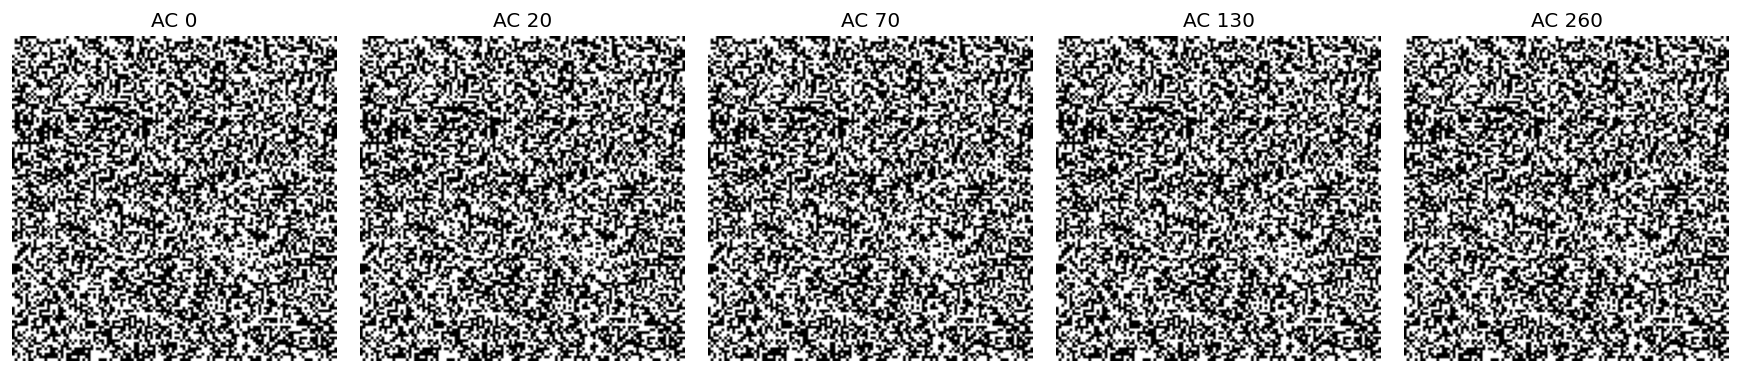

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(14.5, 3), constrained_layout=True)
for ax, U, t in zip(axes, ac, [0, 20, 70, 130, 260]):
    ax.imshow(U, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"AC {t}"); ax.axis("off")
fig.savefig(OUT / "allen_cahn_panel.png", bbox_inches="tight")
plt.show()


## Part B: Cahn-Hilliard evolution


In [4]:
u = u0.copy()
ch = [u.copy()]
for k in range(340):
    lap_u = (np.roll(u,1,0)+np.roll(u,-1,0)+np.roll(u,1,1)+np.roll(u,-1,1)-4*u)
    mu = -(eps**2) * lap_u + (u**3 - u)
    lap_mu = (np.roll(mu,1,0)+np.roll(mu,-1,0)+np.roll(mu,1,1)+np.roll(mu,-1,1)-4*mu)
    u = u + dt_ch * lap_mu
    u = np.clip(u, -1.3, 1.3)
    if k in [30, 100, 220, 339]:
        ch.append(u.copy())


### Render the conserved evolution

The following panel compares the same initial condition across the saved Cahn--Hilliard times, making the slower coarsening dynamics directly visible.

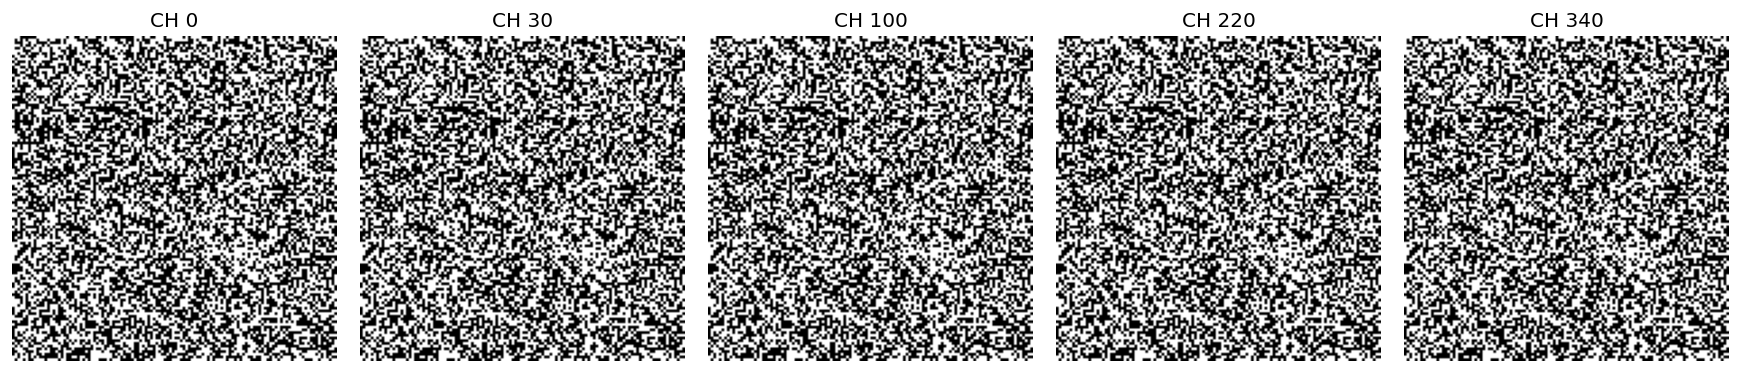

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(14.5, 3), constrained_layout=True)
for ax, U, t in zip(axes, ch, [0, 30, 100, 220, 340]):
    ax.imshow(U, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"CH {t}"); ax.axis("off")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive cell: choose PDE and step


## Bibliographical resources

- Allen, S. M. and Cahn, J. W. (1979). A microscopic theory for antiphase boundary motion and its application to antiphase domain coarsening. *Acta Metallurgica*, 27, 1085--1095.
- Cahn, J. W. and Hilliard, J. E. (1958). Free energy of a nonuniform system. I. Interfacial free energy. *Journal of Chemical Physics*, 28, 258--267.
- Bray, A. J. (1994). Theory of phase-ordering kinetics. *Advances in Physics*, 43, 357--459.